<a href="https://colab.research.google.com/github/saimanhamal/ok/blob/main/tu4(keras).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [26]:
import os
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models
from tensorflow.keras.datasets import mnist
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.layers import Dense
from tensorflow.keras.models import Sequential
from tensorflow.keras.optimizers import SGD
import matplotlib.pyplot as plt
import time

In [27]:
print("Keras Version:", tf.keras.__version__)

Keras Version: 3.13.2


In [28]:
def f(x):
    return x ** 2

def gradient(x):
    return 2 * x

x = 5.0
learning_rate = 0.1

for _ in range(10):
    x -= learning_rate * gradient(x)
    print(f"x: {x:.4f}, f(x): {f(x):.4f}")

x: 4.0000, f(x): 16.0000
x: 3.2000, f(x): 10.2400
x: 2.5600, f(x): 6.5536
x: 2.0480, f(x): 4.1943
x: 1.6384, f(x): 2.6844
x: 1.3107, f(x): 1.7180
x: 1.0486, f(x): 1.0995
x: 0.8389, f(x): 0.7037
x: 0.6711, f(x): 0.4504
x: 0.5369, f(x): 0.2882


In [29]:
x = tf.Variable(5.0)

with tf.GradientTape() as tape:
    y = x ** 2

grad = tape.gradient(y, x)
print("Gradient:", grad.numpy())

Gradient: 10.0


In [30]:
size = (1000, 1000)
A = np.random.rand(*size)
B = np.random.rand(*size)

start = time.time()
C_numpy = np.dot(A, B)
print("NumPy Time:", round(time.time() - start, 4), "seconds")

A_tf = tf.constant(A)
B_tf = tf.constant(B)
start = time.time()
C_tf = tf.matmul(A_tf, B_tf)
print("TensorFlow Time:", round(time.time() - start, 4), "seconds")

NumPy Time: 0.0358 seconds
TensorFlow Time: 0.0006 seconds


In [31]:
layer = Dense(64, activation='sigmoid')
print("Layer created:", layer)

Layer created: <Dense name=dense_30, built=False>


In [32]:
np.random.seed(42)
x_dummy   = np.random.rand(100, 3)
y_dummy   = np.random.rand(100, 1)
weights   = np.random.randn(3, 1)
learning_rate = 0.01

for epoch in range(10):
    y_pred    = np.dot(x_dummy, weights)
    loss      = np.mean((y_pred - y_dummy) ** 2)
    gradients = 2 * np.dot(x_dummy.T, (y_pred - y_dummy)) / len(x_dummy)
    weights  -= learning_rate * gradients
    print(f"Epoch {epoch+1} — Loss: {loss:.4f}")

Epoch 1 — Loss: 0.4674
Epoch 2 — Loss: 0.4574
Epoch 3 — Loss: 0.4478
Epoch 4 — Loss: 0.4385
Epoch 5 — Loss: 0.4295
Epoch 6 — Loss: 0.4207
Epoch 7 — Loss: 0.4123
Epoch 8 — Loss: 0.4041
Epoch 9 — Loss: 0.3962
Epoch 10 — Loss: 0.3885


In [33]:
x_dummy = np.random.rand(100, 3)
y_dummy = np.random.rand(100, 1)

simple_model = Sequential([
    Dense(64, activation='relu', input_shape=(3,)),
    Dense(1)
])

simple_model.compile(optimizer='sgd', loss='mse')
simple_model.fit(x_dummy, y_dummy, epochs=10, batch_size=32, verbose=1)

Epoch 1/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 72ms/step - loss: 0.2432
Epoch 2/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.1830 
Epoch 3/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.1445
Epoch 4/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.1228 
Epoch 5/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.1051 
Epoch 6/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.1025 
Epoch 7/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0963 
Epoch 8/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0936 
Epoch 9/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0918 
Epoch 10/10
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0913 


In [34]:
learning_rate = 0.01
weights = np.random.randn(3, 3)

for _ in range(100):
    grad     = np.random.randn(3, 3)
    weights -= learning_rate * grad

print("Final weights:\n", weights)

Final weights:
 [[-0.44034362 -1.02769808 -0.32135497]
 [-0.13362529  1.02098208 -1.89556417]
 [ 1.71329155 -0.22060015 -0.4690653 ]]


In [35]:
optimizer = SGD(learning_rate=0.01)
print("Keras SGD optimizer ready.")

Keras SGD optimizer ready.


In [36]:
layer = Dense(
    units=64,
    activation=None,
    use_bias=True,
    kernel_initializer="glorot_uniform"
)
print("Dense layer created:", layer)

Dense layer created: <Dense name=dense_33, built=False>


Train: (60000, 784) (60000, 10)
Test:  (10000, 784) (10000, 10)


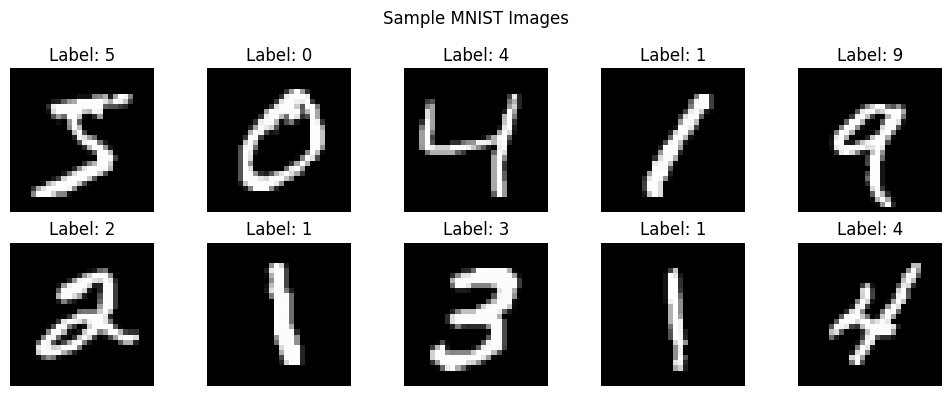

In [37]:
(x_train, y_train), (x_test, y_test) = mnist.load_data()

# Normalize
x_train, x_test = x_train / 255.0, x_test / 255.0

# Flatten to 784
x_train = x_train.reshape(-1, 28 * 28)
x_test  = x_test.reshape(-1,  28 * 28)

# One-hot encode
y_train = to_categorical(y_train, 10)
y_test  = to_categorical(y_test,  10)

print("Train:", x_train.shape, y_train.shape)
print("Test: ", x_test.shape,  y_test.shape)

# Visualise samples
plt.figure(figsize=(10, 4))
for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(x_train[i].reshape(28, 28), cmap='gray')
    plt.title(f"Label: {np.argmax(y_train[i])}")
    plt.axis("off")
plt.suptitle("Sample MNIST Images")
plt.tight_layout()
plt.show()

In [38]:
model = keras.Sequential([
    keras.layers.Input(shape=(784,)),
    keras.layers.Dense(64,  activation="sigmoid"),
    keras.layers.Dense(128, activation="sigmoid"),
    keras.layers.Dense(256, activation="sigmoid"),
    keras.layers.Dense(10,  activation="softmax"),
])

model.summary()

Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_34 (Dense)                │ (None, 64)             │        50,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_35 (Dense)                │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_36 (Dense)                │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_37 (Dense)                │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 94,154 (367.79 KB)

 Trainable params: 94,154 (367.79 KB)

 Non-trainable params: 0 (0.00 B)

In [39]:
def build_functional_model():
    inputs  = keras.Input(shape=(784,))
    x       = keras.layers.Dense(64,  activation="sigmoid")(inputs)
    x       = keras.layers.Dense(128, activation="sigmoid")(x)
    x       = keras.layers.Dense(256, activation="sigmoid")(x)
    outputs = keras.layers.Dense(10,  activation="softmax")(x)
    return keras.Model(inputs=inputs, outputs=outputs)

functional_model = build_functional_model()
functional_model.summary()

Model: "functional_10"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_10 (InputLayer)     │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_38 (Dense)                │ (None, 64)             │        50,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_39 (Dense)                │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_40 (Dense)                │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_41 (Dense)                │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 94,154 (367.79 KB)

 Trainable params: 94,154 (367.79 KB)

 Non-trainable params: 0 (0.00 B)

In [40]:
model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)
print("Model compiled.")

Model compiled.


In [42]:
callbacks = [
    keras.callbacks.ModelCheckpoint(
        filepath="model_at_epoch_{epoch}.keras"
    ),
    keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=4,
        verbose=1
    ),
]

history = model.fit(
    x_train,
    y_train,
    batch_size=128,
    epochs=2000,
    validation_split=0.15,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/2000
399/399 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9917 - loss: 0.0302 - val_accuracy: 0.9702 - val_loss: 0.1114
Epoch 2/2000
399/399 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9926 - loss: 0.0260 - val_accuracy: 0.9704 - val_loss: 0.1165
Epoch 3/2000
399/399 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9933 - loss: 0.0238 - val_accuracy: 0.9712 - val_loss: 0.1164
Epoch 4/2000
399/399 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9940 - loss: 0.0213 - val_accuracy: 0.9713 - val_loss: 0.1163
Epoch 5/2000
399/399 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9938 - loss: 0.0210 - val_accuracy: 0.9696 - val_loss: 0.1329
Epoch 5: early stopping


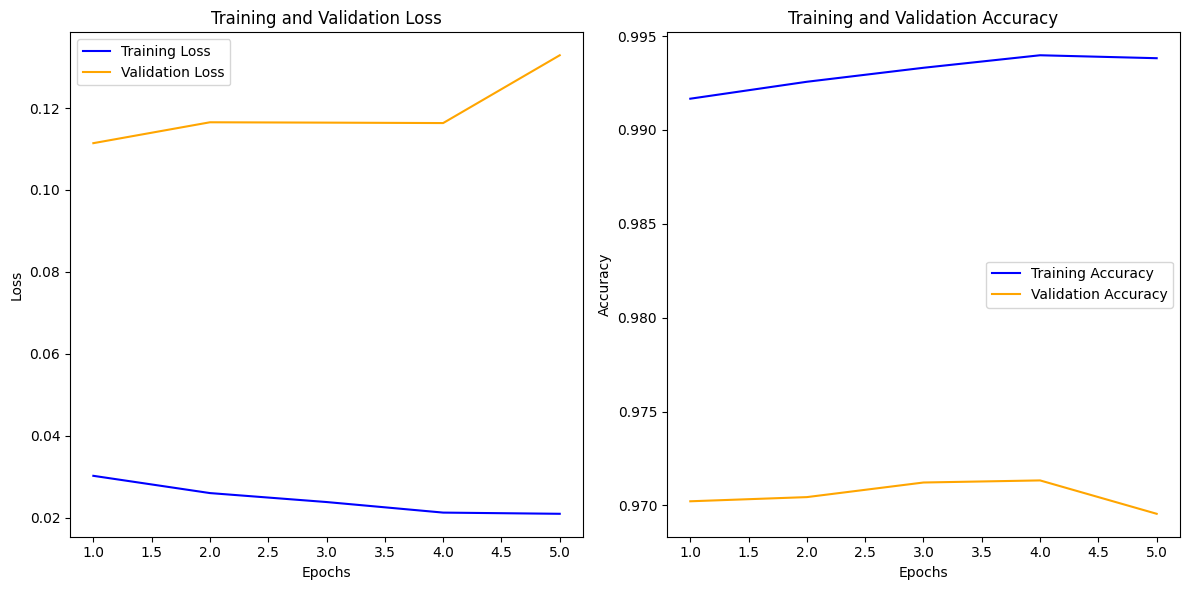

In [43]:
train_loss = history.history['loss']
val_loss   = history.history['val_loss']
train_acc  = history.history['accuracy']
val_acc    = history.history['val_accuracy']

plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.plot(range(1, len(train_loss) + 1), train_loss, label='Training Loss',   color='blue')
plt.plot(range(1, len(val_loss)   + 1), val_loss,   label='Validation Loss', color='orange')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(range(1, len(train_acc) + 1), train_acc, label='Training Accuracy',   color='blue')
plt.plot(range(1, len(val_acc)   + 1), val_acc,   label='Validation Accuracy', color='orange')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Training and Validation Accuracy')
plt.legend()

plt.tight_layout()
plt.show()

In [44]:
test_loss, test_acc = model.evaluate(x_test, y_test, verbose=2)
print(f"Test Loss:     {test_loss:.4f}")
print(f"Test Accuracy: {test_acc:.4f}")

313/313 - 2s - 6ms/step - accuracy: 0.9712 - loss: 0.1228
Test Loss:     0.1228
Test Accuracy: 0.9712


313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
Predicted label for first image: 7
True label for first image:      7


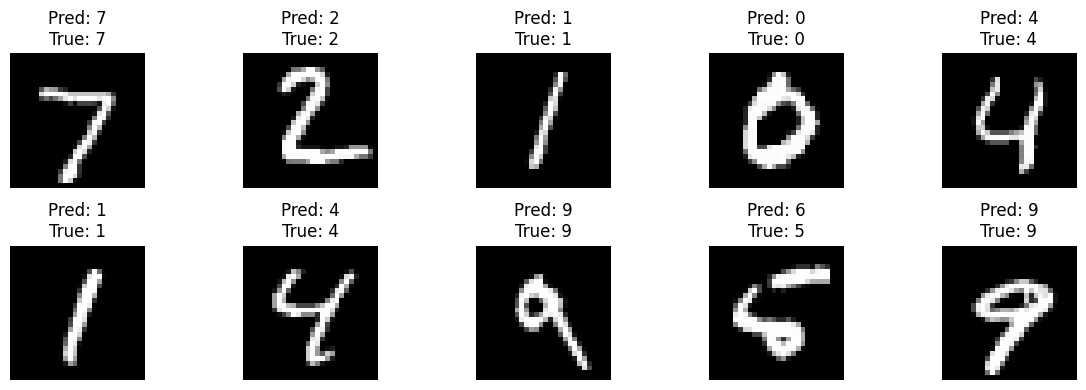

In [45]:
predictions      = model.predict(x_test)
predicted_labels = np.argmax(predictions, axis=1)

print(f"Predicted label for first image: {predicted_labels[0]}")
print(f"True label for first image:      {np.argmax(y_test[0])}")

# Visualise predictions
plt.figure(figsize=(12, 4))
for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(x_test[i].reshape(28, 28), cmap='gray')
    plt.title(f"Pred: {predicted_labels[i]}\nTrue: {np.argmax(y_test[i])}")
    plt.axis("off")
plt.tight_layout()
plt.show()

In [46]:
model.save('mnist_fully_connected_model.h5')
print("Model saved.")

Model saved.


In [47]:
loaded_model = tf.keras.models.load_model('mnist_fully_connected_model.h5')
print("Model loaded.")
loaded_model.summary()

Model loaded.


Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_34 (Dense)                │ (None, 64)             │        50,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_35 (Dense)                │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_36 (Dense)                │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_37 (Dense)                │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 94,156 (367.80 KB)

 Trainable params: 94,154 (367.79 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 2 (12.00 B)

In [48]:
loss, acc = loaded_model.evaluate(x_test, y_test, verbose=2)
print(f"Loaded Model — Test Accuracy: {acc:.4f}")

313/313 - 2s - 6ms/step - accuracy: 0.9712 - loss: 0.1228
Loaded Model — Test Accuracy: 0.9712
